<a href="https://colab.research.google.com/github/LUPRWEST/machine-learning/blob/main/food_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# 구글 드라이브
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/data/kaggle_food/"

from google.colab import drive
drive.mount('/content/gdrive')

%cd /content/gdrive/My Drive/data/kaggle_food

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/My Drive/data/kaggle_food


In [58]:
!ls

image


In [44]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from keras.preprocessing.image import ImageDataGenerator

from tensorflow import keras
import matplotlib.pyplot as plt
import numpy
import os 
import tensorflow as tf
import cv2

In [46]:
# 전처리
train_datagen = ImageDataGenerator(rescale= 1./255)
training_set = train_datagen.flow_from_directory('image/train',
                                                 target_size= (288, 288),
                                                 batch_size= 32,
                                                 class_mode= 'categorical')

Found 250 images belonging to 5 classes.


In [47]:
test_datagen = ImageDataGenerator(rescale= 1./255)
test_set = test_datagen.flow_from_directory('image/test',
                                            target_size= (288, 288),
                                            batch_size= 32,
                                            class_mode= 'categorical')

Found 1009 images belonging to 5 classes.


In [56]:
#그거 뭐냐 암튼.. 참고용
from sklearn.preprocessing import LabelEncoder
item = ['bibimbap', 'caprese_salad', 'cup_cakes', 'hamburger', 'pizza']

encoder = LabelEncoder()
encoder.fit(test_set.classes)
result = encoder.transform(test_set.classes)

target = tf.keras.utils.to_categorical(result)
print(target)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [50]:
#model design

model = Sequential()
model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (288,288, 3)))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D( 32,(3, 3), activation = 'relu'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

# fully connected layer 

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(5, activation='sigmoid'))

In [51]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 286, 286, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 143, 143, 32)     0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 141, 141, 32)      9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 70, 70, 32)       0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 156800)            0         
                                                                 
 dense_4 (Dense)             (None, 128)              

In [52]:
#model compile
from tensorflow.keras.optimizers import SGD
model.compile(loss= 'categorical_crossentropy',
              optimizer= 'adam', 
              metrics=['accuracy'])

In [53]:
#model training 
history = model.fit(training_set, epochs=5)

Epoch 1/5
8/8 [==============================] - 37s 4s/step - loss: 3.1420 - accuracy: 0.2000
Epoch 2/5
8/8 [==============================] - 22s 3s/step - loss: 1.5242 - accuracy: 0.3440
Epoch 3/5
8/8 [==============================] - 22s 3s/step - loss: 1.1439 - accuracy: 0.6320
Epoch 4/5
8/8 [==============================] - 22s 3s/step - loss: 0.4581 - accuracy: 0.8920
Epoch 5/5
8/8 [==============================] - 23s 3s/step - loss: 0.1383 - accuracy: 0.9760


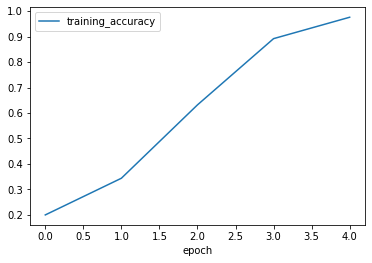

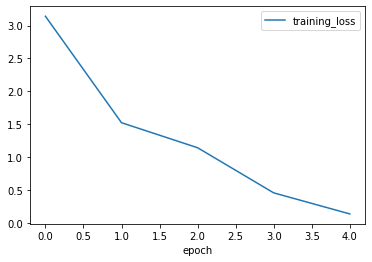

In [54]:
# 정확도(accuracy), 손실(loss) 그래프
plt.figure(1)
plt.xlabel('epoch')
plt.plot(history.history['accuracy'], label='training_accuracy')
plt.legend()
plt.show()

plt.figure(2)
plt.xlabel('epoch')
plt.plot(history.history['loss'], label='training_loss')
plt.legend()
plt.show()